<a href="https://colab.research.google.com/github/polokocodes/Data-Science---ML-Projects/blob/main/EDA_Loan_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1:EDA(Exploratory Data Analysis)

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [59]:
loan_data = pd.read_csv('/content/loan.csv')
loan_data.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [60]:
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [61]:
loan_data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [62]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [63]:
missing_values = loan_data.isnull().sum()

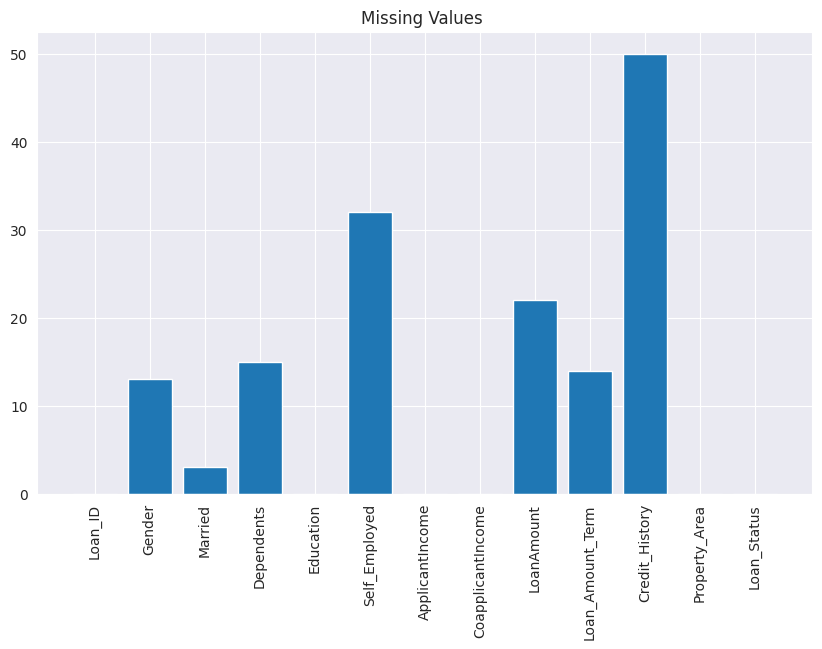

In [64]:
sns.set_style("darkgrid")
plt.figure(figsize=(10, 6))
plt.title('Missing Values ')
plt.bar(missing_values.index, missing_values.values)
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_1304/3839200596.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Approved','Denied'])


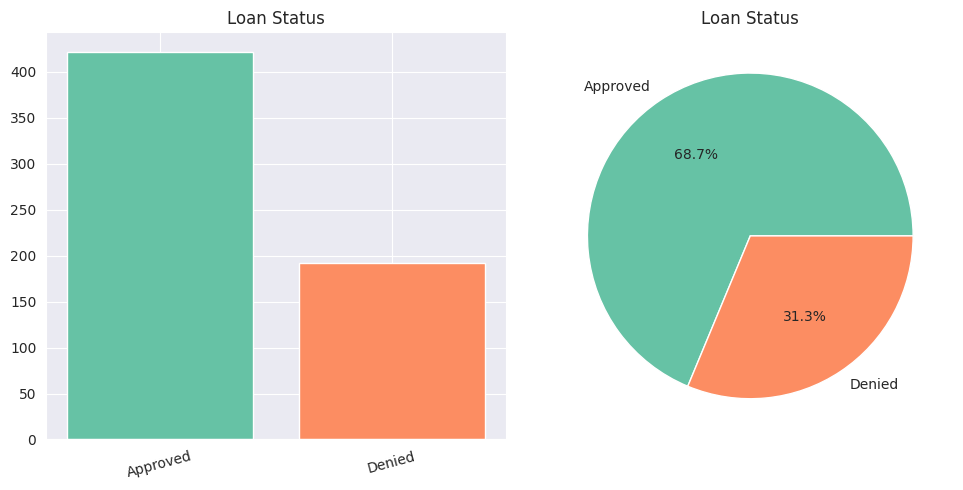

Loan status distribution:68.73%


In [65]:
#Loan Status distribution
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes = axes.flatten()

axes[0].bar(loan_data['Loan_Status'].value_counts().index, loan_data['Loan_Status'].value_counts().values, color=["#66c2a5","#fc8d62"])
axes[0].set_title('Loan Status')
axes[0].set_xticklabels(['Approved','Denied'])
axes[0].tick_params(axis = 'x', rotation = 15)

axes[1].pie(loan_data['Loan_Status'].value_counts(), labels=["Approved","Denied"], autopct="%1.1f%%",
    colors=["#66c2a5","#fc8d62"])
axes[1].set_title('Loan Status')

plt.tight_layout()
plt.show()

loan_distrubution_per = (loan_data['Loan_Status'] == 'Y').mean() *100
print(f"Loan status distribution:{loan_distrubution_per:.2f}%")

In [66]:
# Loan status vs Categorical values
loan_data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [67]:
loan_data['Gender'].head()

,Gender
0,Male
1,Male
2,Male
3,Male
4,Male


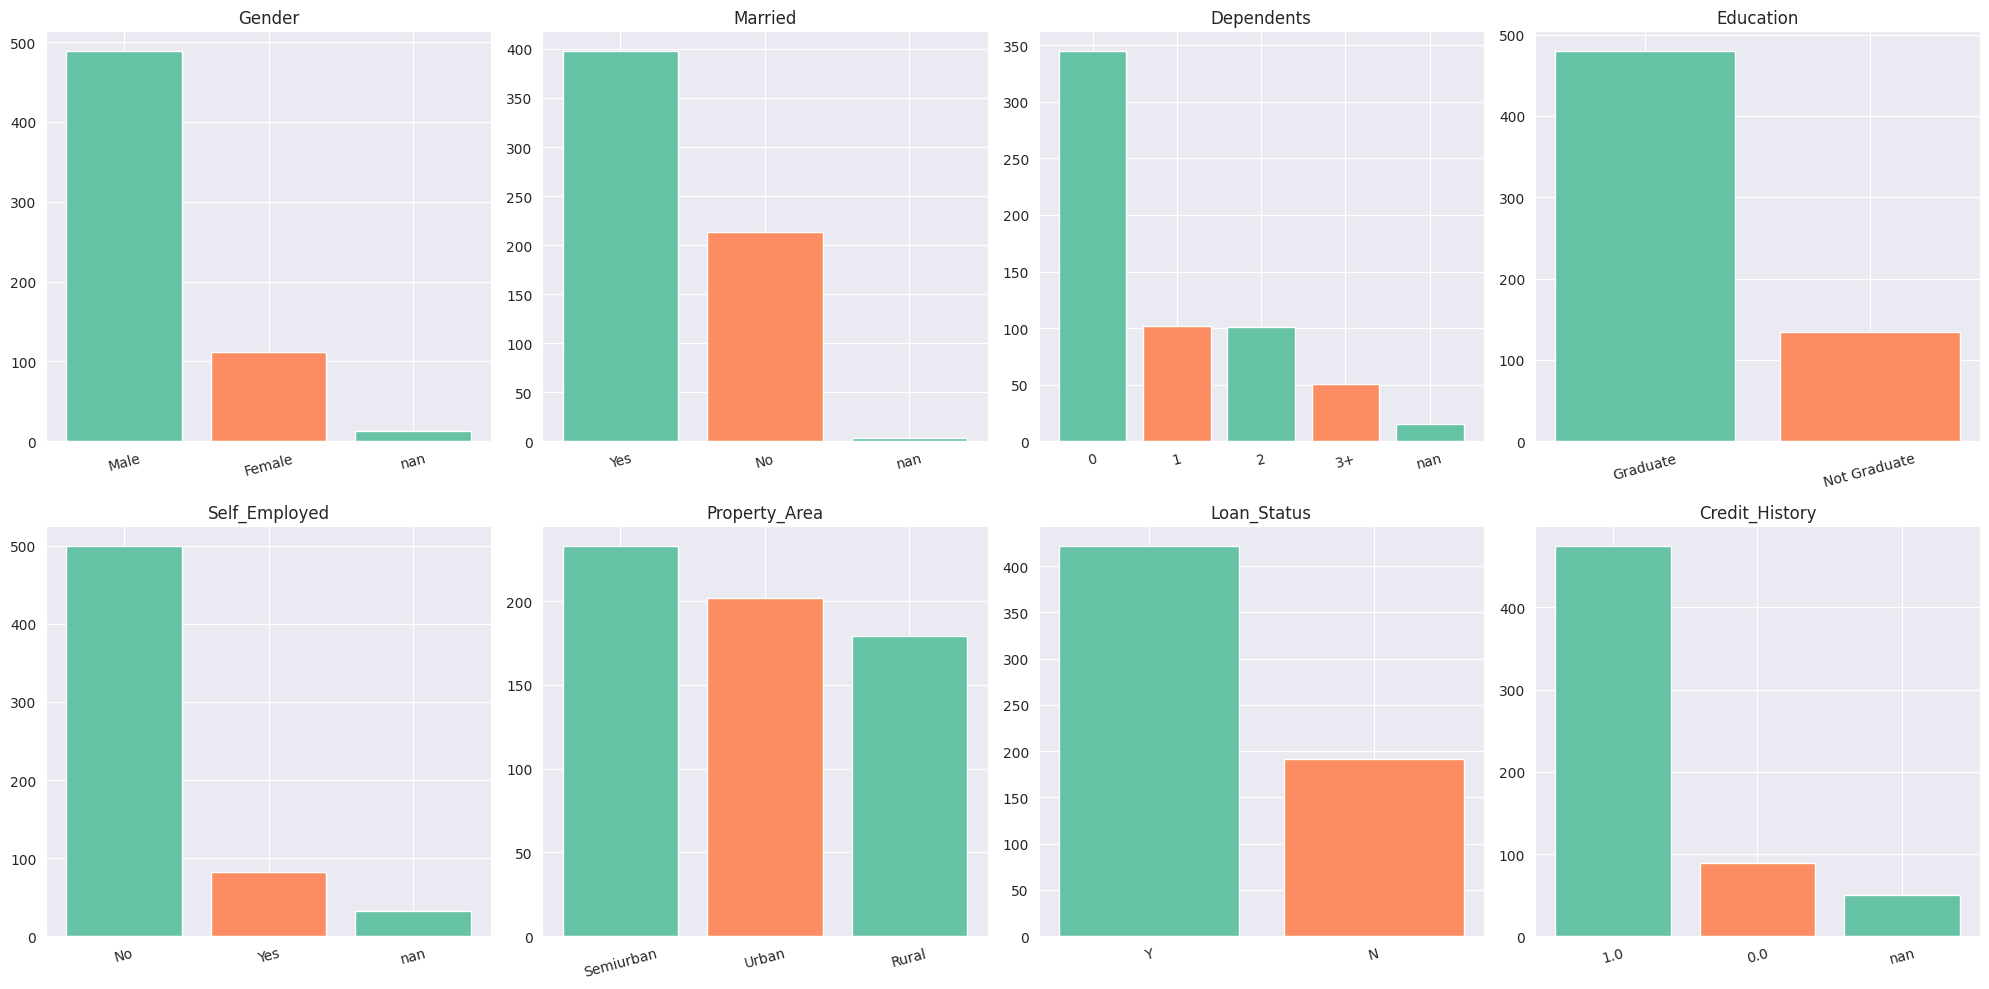

In [68]:
#Categorical features EDA
#Univariate Cartegorical features
cartegorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status','Credit_History']

fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.flatten()

for i, col in enumerate(cartegorical_features):
  counts = loan_data[col].value_counts(dropna=False)
  labels = [str(x)for x in counts.index]
  axes[i].bar(labels, counts.values, color = ["#66c2a5","#fc8d62"])
  axes[i].set_title(col)
  axes[i].tick_params(axis='x', rotation=15)
#for j in range(len(cartegorical_features), len(axes)):
 # axes[j].axis('off')

plt.tight_layout()
plt.show()
#


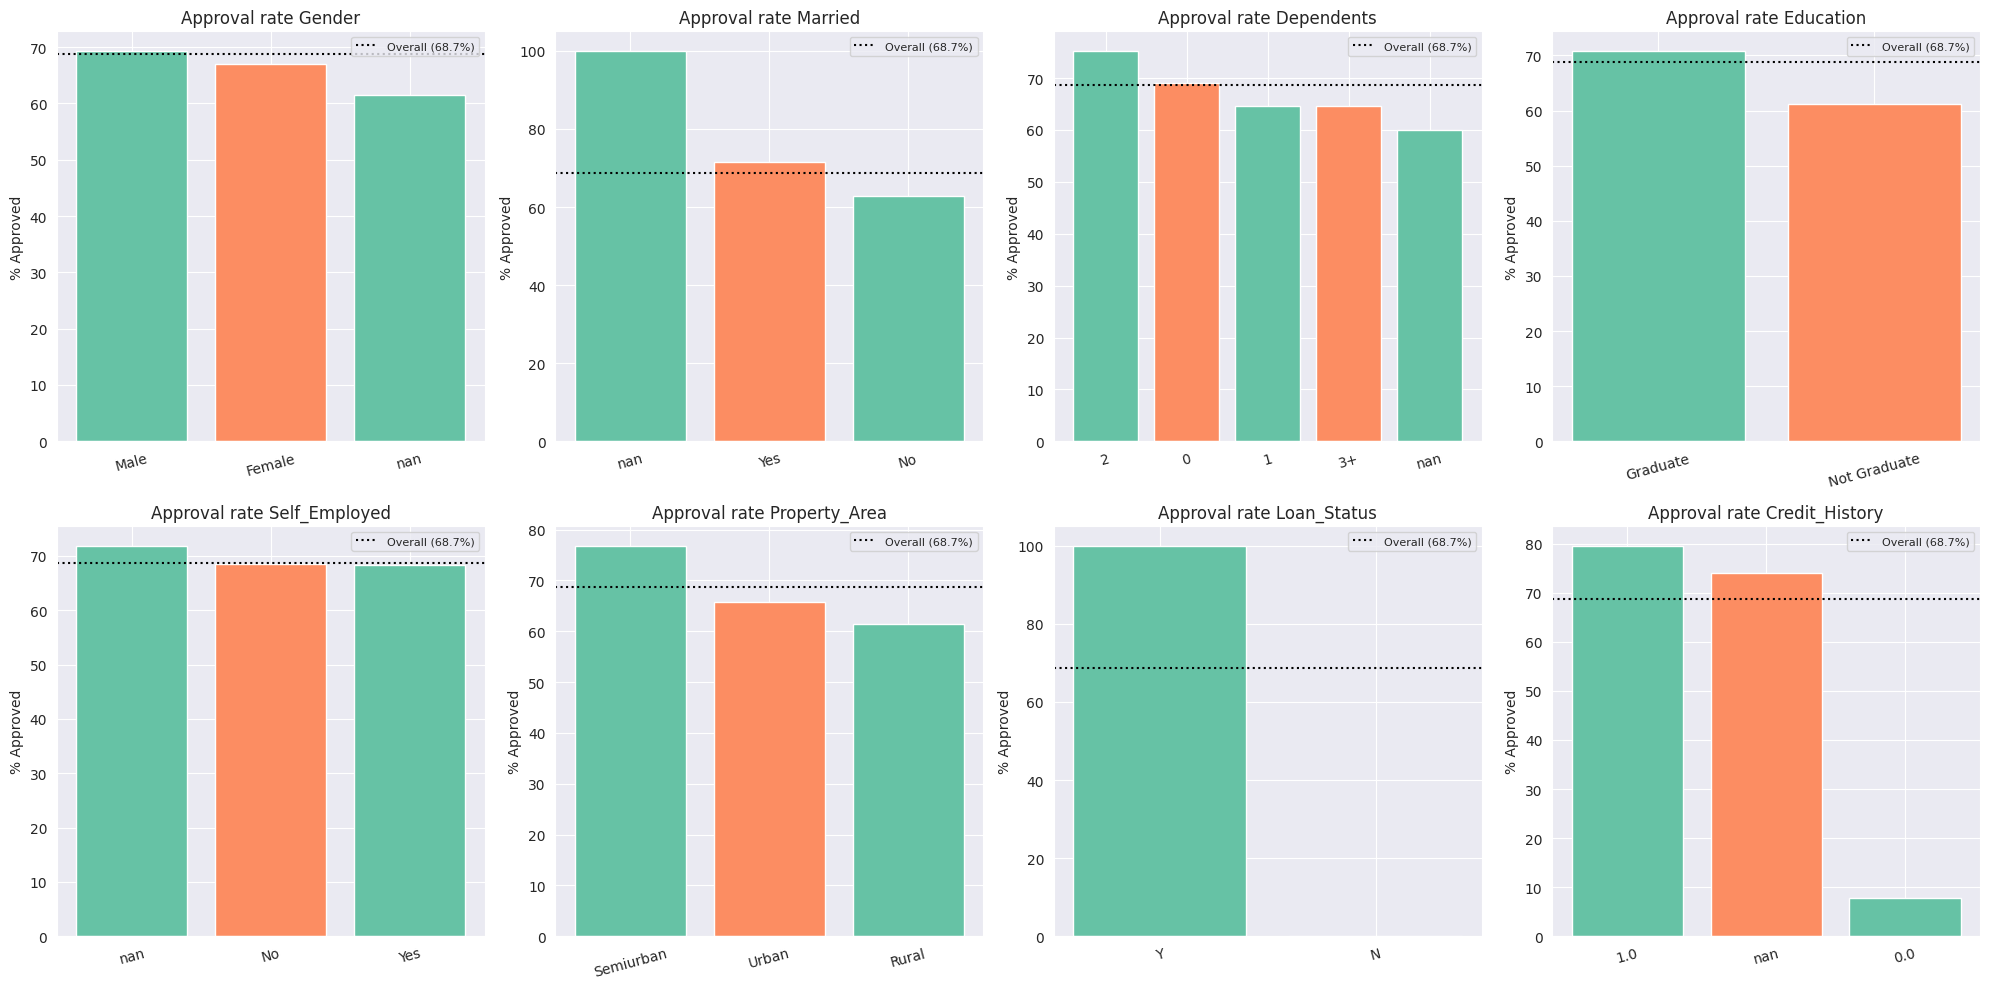

In [69]:
#Bivariate Cartegorical features
# turn Y/N into 1/0 so we can average it
loan_data['target'] = (loan_data['Loan_Status'] == 'Y').astype(int)
overall_rate = loan_data["target"].mean() * 100 # baseline: overall approval rate across everyone

fig, axes = plt.subplots(2,4, figsize=(20,10))
axes = axes.flatten()

for i,col in enumerate(cartegorical_features):
  rate = loan_data.groupby(col,dropna=False)['target'].mean().sort_values(ascending=False)*100
  label = [str(x) for x in rate.index]

  axes[i].bar(label, rate.values, color = ["#66c2a5","#fc8d62"])
  axes[i].set_title(f"Approval rate {col}")
  axes[i].axhline(overall_rate, color = 'black', linestyle = ':', label = f"Overall ({overall_rate:.1f}%)" )
  axes[i].set_ylabel('% Approved')
  axes[i].tick_params(axis='x', rotation=15)
  axes[i].legend(fontsize = 8)

for j in range(len(cartegorical_features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [70]:
loan_data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


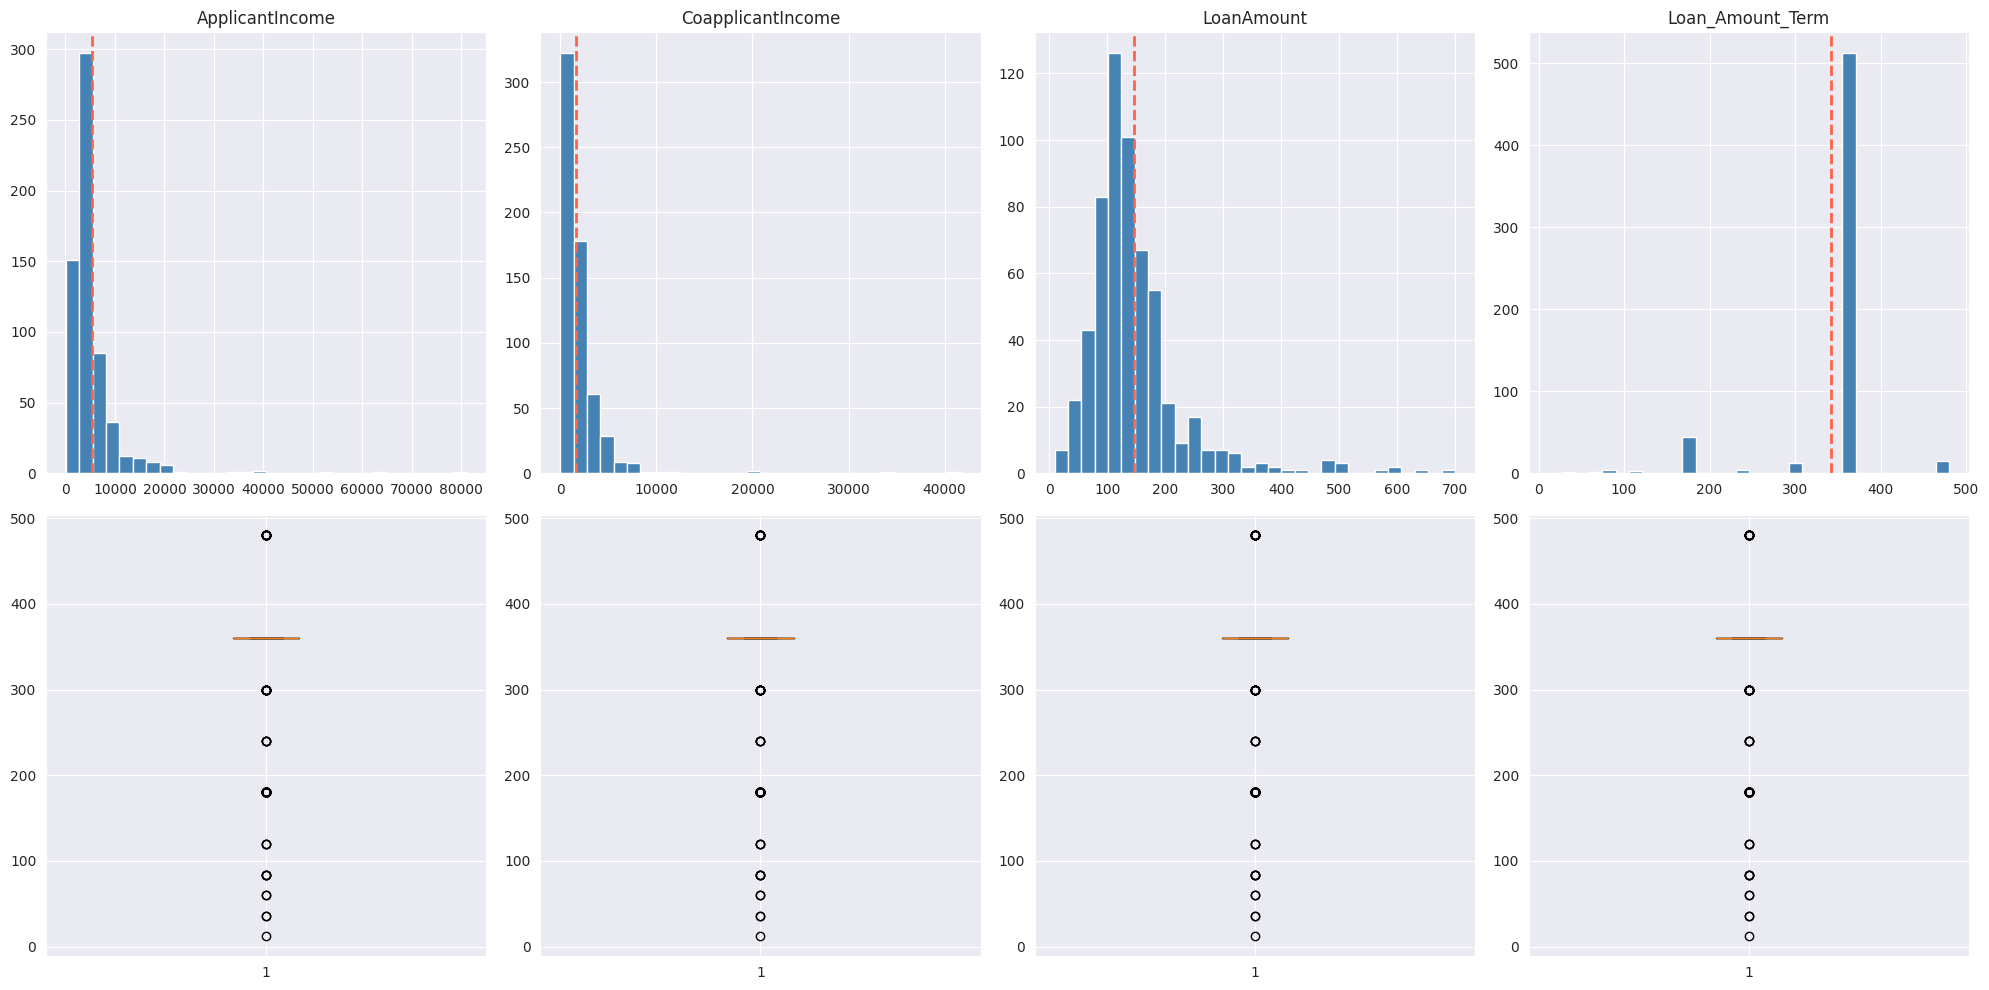

In [71]:
#Numerical Categories
#Univariate

numerical_categories = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(numerical_categories):
    data = loan_data[col].dropna()          # just this column's values, missing ones removed
    axes[0,i].hist(data, bins=30, color='steelblue')
    axes[0,i].axvline(data.mean(), color='tomato', linestyle='dashed', linewidth=2, label='Mean')
    axes[0,i].set_title(col)


for i, col in enumerate(numerical_categories):

  axes[1,i].boxplot(data)

plt.tight_layout()
plt.show()

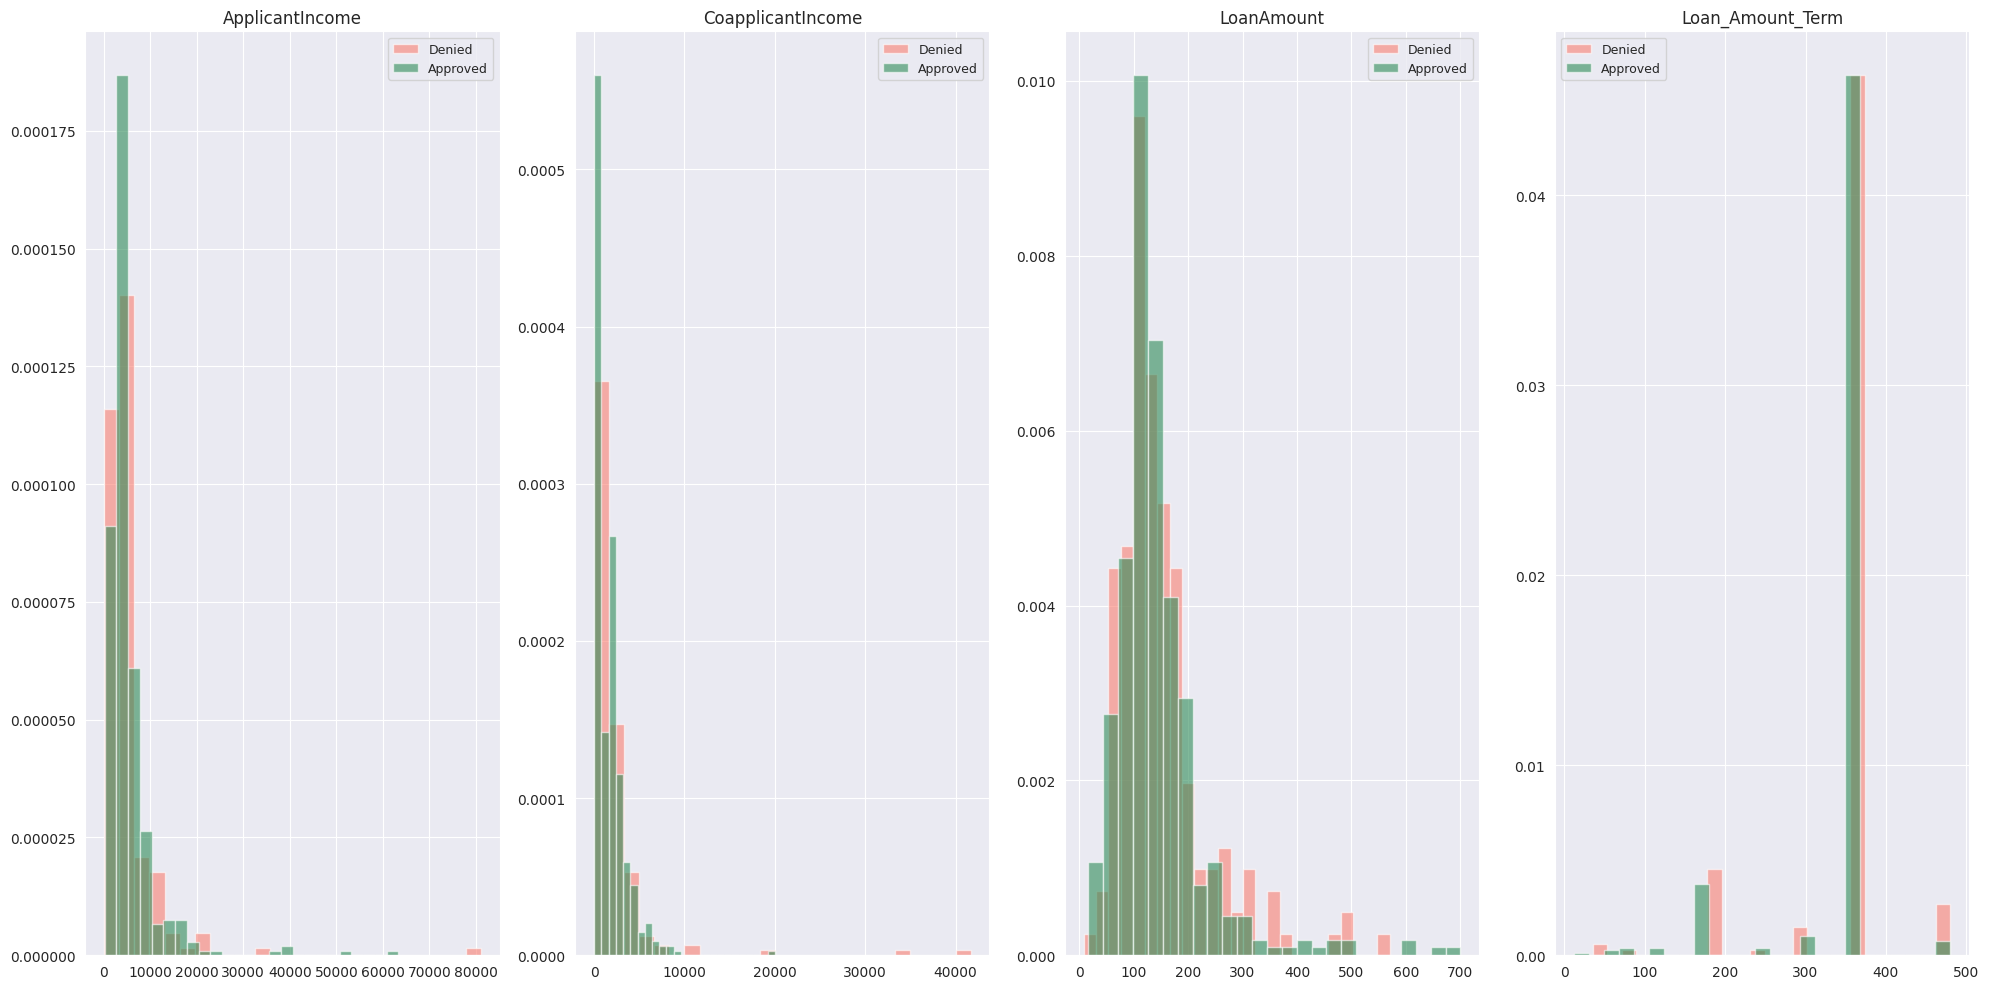

In [72]:
#Bivariate numerical values

fig, axes = plt.subplots(1,4, figsize=(20,10))

for i, col in enumerate(numerical_categories):
  for s, color, label in [(0, "salmon", "Denied"), (1, "seagreen", "Approved")]:
        sub = loan_data[loan_data["target"] == s][col].dropna()
        axes[i].hist(sub, bins=25, alpha=0.6, color=color, label=label, density=True)
        axes[i].set_title(col)
        axes[i].legend(fontsize=9)


plt.tight_layout()
plt.show()

#13. Key EDA Findings

1	Class balance: 68.7% approved vs 31.3% denied — moderately imbalanced

2	Credit_History is the dominant predictor: 79% approval when Credit_History == 1, 8% when Credit_History == 0

3	Married applicants are approved more often (71%) than singles (63%)

4	Education matters: graduates get approved more (71%) than non-graduates (61%)

5	Property_Area = Semiurban has the highest approval rate (77%) — even higher than Urban

6	Income is mildly informative: approved applicants have slightly lower mean income (5384) than denied (5446) — counterintuitive at first glance, explained by Credit_History being more important

7	6 of 12 columns have missing values (Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, Credit_History) — need careful imputation

8	Dependents = "3+" is a string token that needs to become 3 for numeric handling

# Step 2: Data cleaning & Feature Engineering

#Loan Approval — Data Cleaning & Feature Engineering
Pipeline:

1.Drop Loan_ID

2.Encode Loan_Status (Y -> 1, N -> 0)

3.Normalize Dependents ("3+" -> 3)

4.Impute missing values (mode for categorical, median for numeric)

5.Engineer TotalIncome, EMI, BalanceIncome, log-transforms for skewed columns

6.One-hot encode the remaining categorical features

7.Save to data/loan_cleaned.csv

# Data Preparations

In [73]:
#Drop LoanID
loan_data = loan_data.drop('Loan_ID', axis=1)

In [74]:
loan_data['Loan_Status'] = (loan_data['Loan_Status'].map({'Y':1, 'N':0}))

In [75]:
loan_data['Dependents'] = loan_data['Dependents'].replace({'3+':3})

In [76]:
missing_data = loan_data.isnull().sum()
print(missing_data[missing_data>0])

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


In [77]:
loan_data['Loan_Status'].isnull().sum()

np.int64(0)

#Impute Missing Values

In [78]:
categorical_data = ['Gender', 'Married', 'Dependents',  'Self_Employed','Credit_History']
numeric_data = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

for i in categorical_data:
  loan_data[i] = loan_data[i].fillna(loan_data[i].mode()[0])

for i in numeric_data:
  loan_data[i] = loan_data[i].fillna(loan_data[i].median())


loan_data['Dependents'] = loan_data['Dependents'].astype(int)

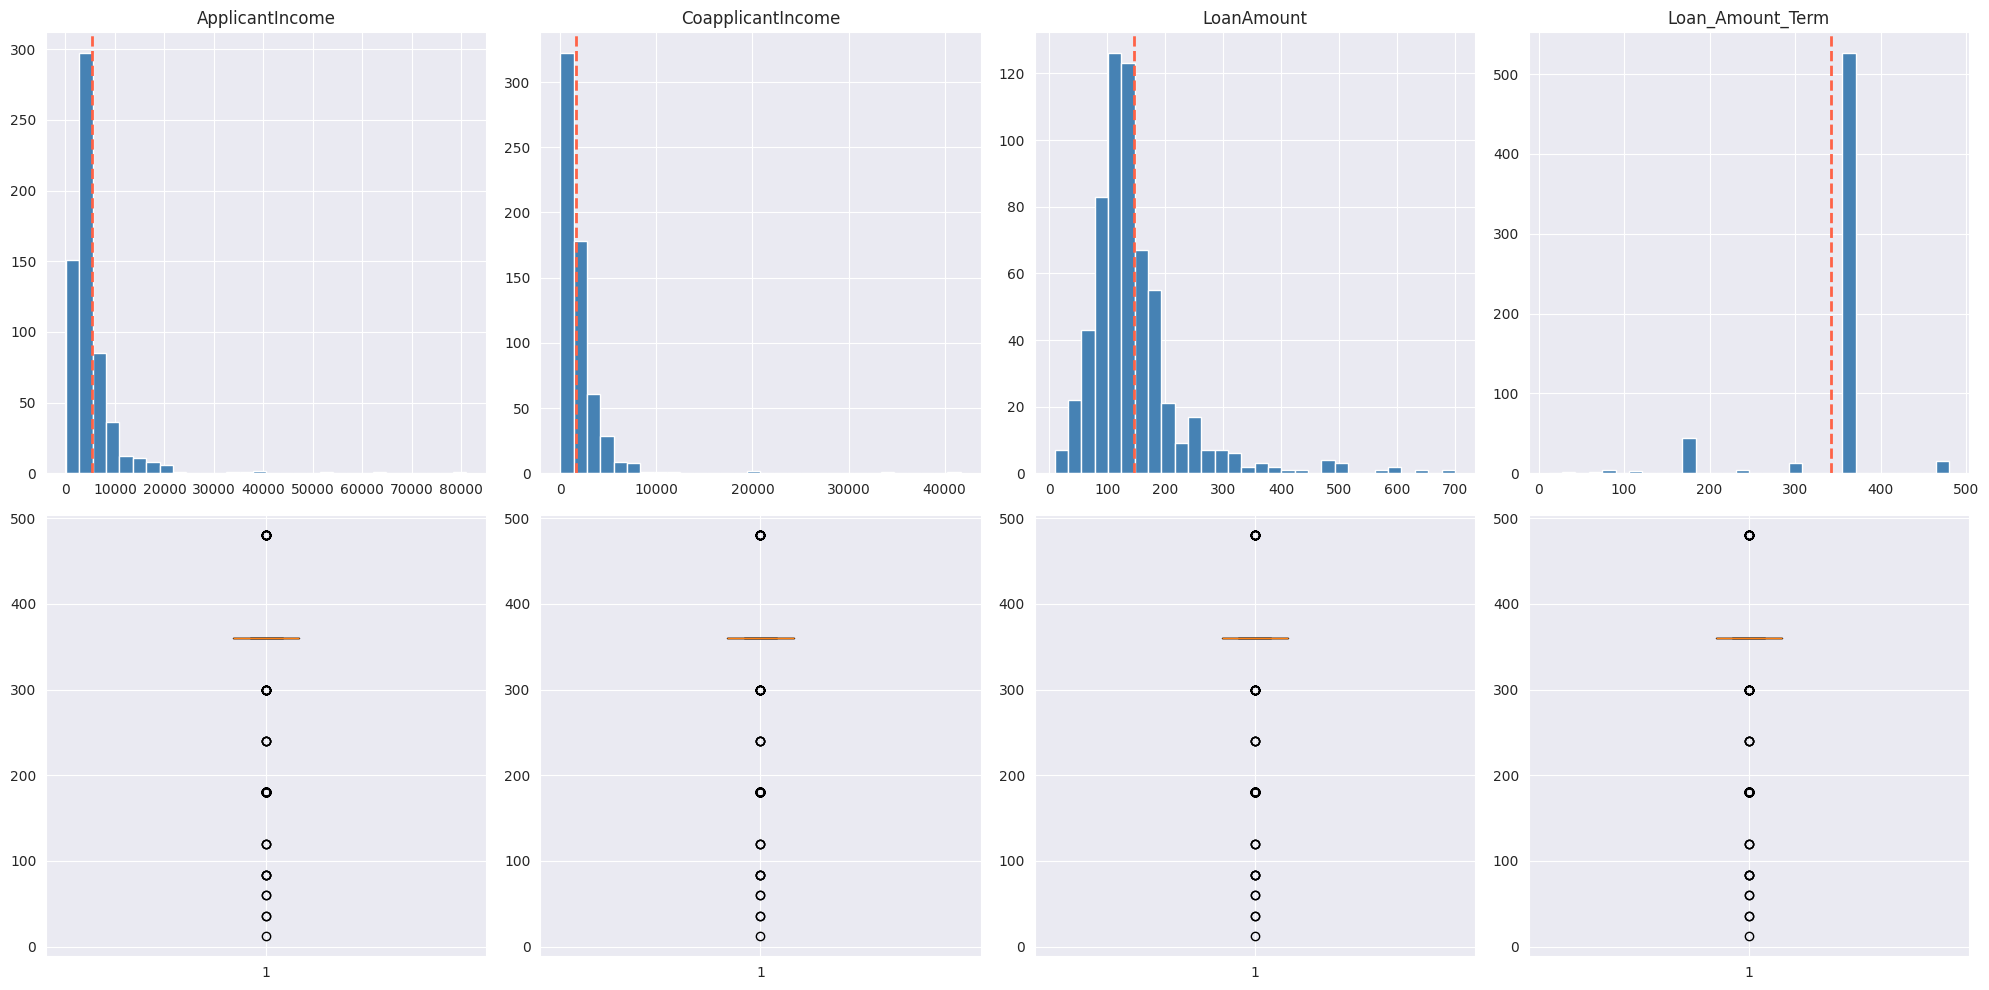

In [81]:
#Numerical data after imputation

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(numeric_data):
    data = loan_data[col].dropna()          # just this column's values, missing ones removed
    axes[0,i].hist(data, bins=30, color='steelblue')
    axes[0,i].axvline(data.mean(), color='tomato', linestyle='dashed', linewidth=2, label='Mean')
    axes[0,i].set_title(col)


for i, col in enumerate(numeric_data):

  axes[1,i].boxplot(data)

plt.tight_layout()
plt.show()

# Feature Engineering

In [83]:
loan_data['TotalIncome'] = loan_data['ApplicantIncome'] + loan_data['CoapplicantIncome']
loan_data['EMI'] = loan_data['LoanAmount'] / loan_data['Loan_Amount_Term']
loan_data['BalanceIncome'] = loan_data['TotalIncome'] - loan_data['EMI']
loan_data['LoanAmount_log'] = loan_data['LoanAmount'].apply(lambda x: np.log(x))
loan_data['TotalIncome_log'] = loan_data['TotalIncome'].apply(lambda x: np.log(x))

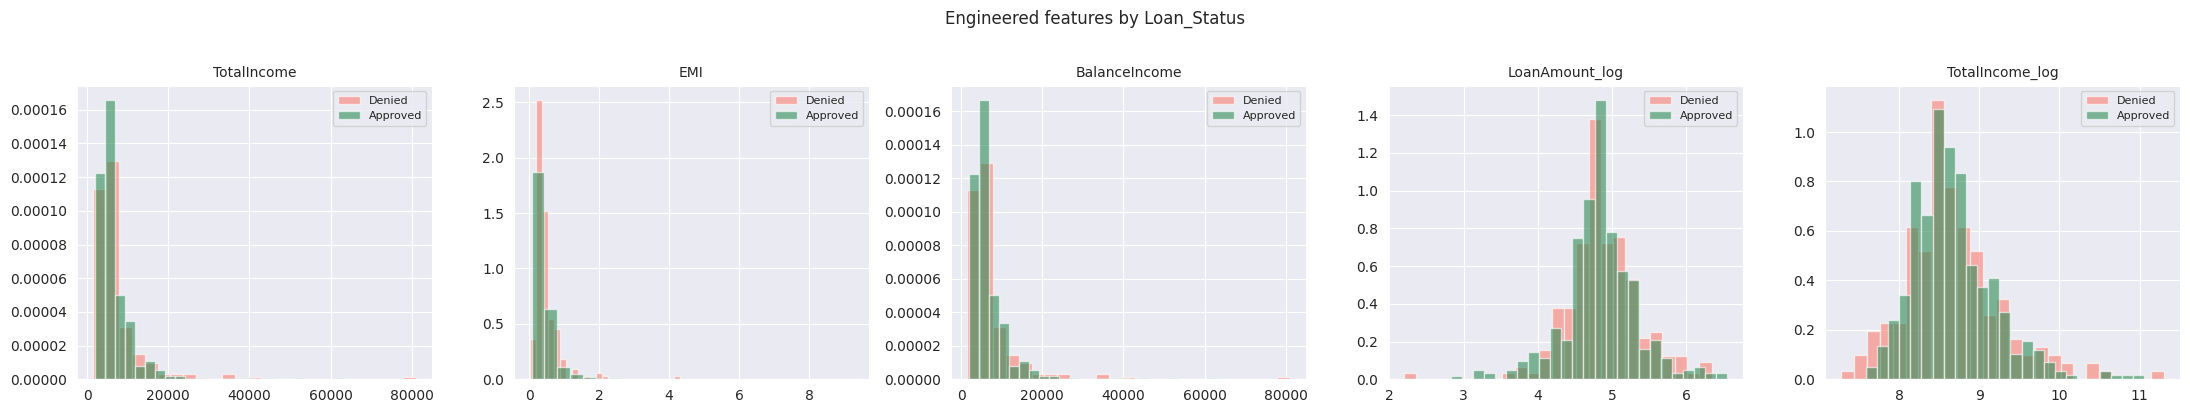

In [84]:
new_cols = ['TotalIncome', 'EMI', 'BalanceIncome', 'LoanAmount_log', 'TotalIncome_log']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, col in enumerate(new_cols):
    for s, color, label in [(0, "salmon", "Denied"), (1, "seagreen", "Approved")]:
        sub = loan_data[loan_data["target"] == s][col].dropna()
        axes[i].hist(sub, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10); axes[i].legend(fontsize=8)
plt.suptitle("Engineered features by Loan_Status", y=1.02)
plt.tight_layout(); plt.show()

# Run the Full Pipeline

In [87]:
loan_data_processed = pd.get_dummies(loan_data, drop_first=True)
print(loan_data_processed.head())

   Dependents  ApplicantIncome  CoapplicantIncome  LoanAmount  \
0           0             5849                0.0       128.0   
1           1             4583             1508.0       128.0   
2           0             3000                0.0        66.0   
3           0             2583             2358.0       120.0   
4           0             6000                0.0       141.0   

   Loan_Amount_Term  Credit_History  Loan_Status  target  TotalIncome  \
0             360.0             1.0            1       1       5849.0   
1             360.0             1.0            0       0       6091.0   
2             360.0             1.0            1       1       3000.0   
3             360.0             1.0            1       1       4941.0   
4             360.0             1.0            1       1       6000.0   

        EMI  BalanceIncome  LoanAmount_log  TotalIncome_log  Gender_Male  \
0  0.355556    5848.644444        4.852030         8.674026         True   
1  0.355556    609

# Sanity Checks & Save

In [88]:
assert loan_data_processed["Loan_Status"].isin([0, 1]).all()
assert loan_data_processed.isnull().sum().sum() == 0
assert "Loan_ID" not in loan_data_processed.columns
print("All checks passed.")

All checks passed.


In [90]:
loan_data_processed.to_csv("/loan_cleaned.csv", index=False)
print(f"Saved data/loan_cleaned.csv ({loan_data_processed.shape[0]} rows, {loan_data_processed.shape[1]} cols)")

Saved data/loan_cleaned.csv (614 rows, 19 cols)


In [91]:
loan_cleaned_data = pd.read_csv('/loan_cleaned.csv')
loan_cleaned_data.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,target,TotalIncome,EMI,BalanceIncome,LoanAmount_log,TotalIncome_log,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,128.0,360.0,1.0,1,1,5849.0,0.355556,5848.644444,4.852030,8.674026,True,False,False,False,False,True
1,1,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,0.355556,6090.644444,4.852030,8.714568,True,True,False,False,False,False
2,0,3000,0.0,66.0,360.0,1.0,1,1,3000.0,0.183333,2999.816667,4.189655,8.006368,True,True,False,True,False,True
3,0,2583,2358.0,120.0,360.0,1.0,1,1,4941.0,0.333333,4940.666667,4.787492,8.505323,True,True,True,False,False,True
4,0,6000,0.0,141.0,360.0,1.0,1,1,6000.0,0.391667,5999.608333,4.948760,8.699515,True,False,False,False,False,True
